# Income Prediction Project
### This Project is related to AI College Course 
##### Aimed to Preprocess the given data very well, then make models to Classify between 2 types of Income <=50 & >50, so using classification models like SVM, DT, RF & Logistic Regression, while before using models we need to clean the data & drop unrelated features.
---


##### Importing Libraries needed in the Project

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Cleansing Data Step
##### Started to load train file then setting the value of nulls as `?`, then knowing the number of duplicated rows to drop them, then droping `education` column due to existing `education num` column that represent the education.
---
##### Now we should now the percentage of rows that have nulls because if it was high percent we should fill it with mean,median or mode by we found that the percent not high, but to be sure that the nulls not biased to specific column we display the percent of nulls in each column & we found that the nulls not biases in specific column, is distributed to columns, So we drop them.

In [2]:
# Recheck the path before running that locally
dataFrame=pd.read_csv("../train_data.csv",na_values=['?'],skipinitialspace=[True])
dataFrame.head(30)
print("Number of Duplicated rows:",dataFrame.duplicated().sum())
print('----------------------------------------')
#droping duplicated rows
df_no_duplicates = dataFrame.drop_duplicates()
#droping education col
df_no_duplicates=df_no_duplicates.drop(columns='education')

mask = df_no_duplicates.isnull().any(axis=1)
print("Precentage of rows have null values according to all rows:",mask.sum()/len(df_no_duplicates))
mask = df_no_duplicates.isnull().sum()
print("\n------------ Percentage of null according to each column ------------\n")
print(mask/len(df_no_duplicates))
print("-----------------------------------")
print("Number of rows before droping rows have nulls:",len(df_no_duplicates))
df_cleaned = df_no_duplicates.dropna()
print("Number of rows after droping rows have nulls:",len(df_cleaned))
df_cleaned.head()


Number of Duplicated rows: 24
----------------------------------------
Precentage of rows have null values according to all rows: 0.07370070996096752

------------ Percentage of null according to each column ------------

age               0.000000
workclass         0.056428
fnlwgt            0.000000
education-num     0.000000
marital-status    0.000000
occupation        0.056643
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.017887
Income            0.000000
dtype: float64
-----------------------------------
Number of rows before droping rows have nulls: 32537
Number of rows after droping rows have nulls: 30139


,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Cleansing Step Cont.
##### As our models not understand Categorical Data we should convert it to numerical data, we used One Hot Encoding Technique that make each real column in our train data to explicit into types putting 1 in the value or column name it have & 0 if is not, then we make Income & Sex manually using dictionary due to less of types (2 types only `0 or 1`) inside, Easier & more correct manually.

In [3]:
print("\n----------- Columns we have in our train dataset -----------\n")
print(df_cleaned.columns)
df = pd.get_dummies(df_cleaned, columns=["workclass", "occupation", "race","marital-status","native-country","relationship"],dtype=int)
sex_dict = {'Male':1,'Female':0}
income_dict = { '>50K' : 1,'<=50K' :0}
print(df.head())
print("\n--------------------------------------------------------------------\n")
#Replacing the categorical data by numerical ones that we make manually.
df['sex'] = df['sex'].replace(sex_dict).astype('int')
df['Income '] = df['Income '].replace(income_dict).astype('int')

print('\n------------------------ DF after Encoding all Rows ------------------------\n')
print(df)
print("\n----------- Columns we have in our train dataset after Encoding -----------\n")
print(df.columns)


----------- Columns we have in our train dataset -----------

Index(['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'Income '],
      dtype='object')
   age  fnlwgt  education-num     sex  capital-gain  capital-loss  \
0   39   77516             13    Male          2174             0   
1   50   83311             13    Male             0             0   
2   38  215646              9    Male             0             0   
3   53  234721              7    Male             0             0   
4   28  338409             13  Female             0             0   

   hours-per-week Income   workclass_Federal-gov  workclass_Local-gov  ...  \
0              40   <=50K                      0                    0  ...   
1              13   <=50K                      0                    0  ...   
2              40   <=50K                      0       

C:\Users\youse\AppData\Local\Temp\ipykernel_7600\3096892410.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace(sex_dict).astype('int')
C:\Users\youse\AppData\Local\Temp\ipykernel_7600\3096892410.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Income '] = df['Income '].replace(income_dict).astype('int')


### Handling Outliers
##### In this stage we clip or remove the extremely high & extremely low values of specific column by calculating it using IQR, after that we correlate the data with each other, meant We see what really affected the traget row `Income` to remain & which not affected or the affect it too small to drop these columns, we use `corr` to know the related features and put threshold `0.05`.

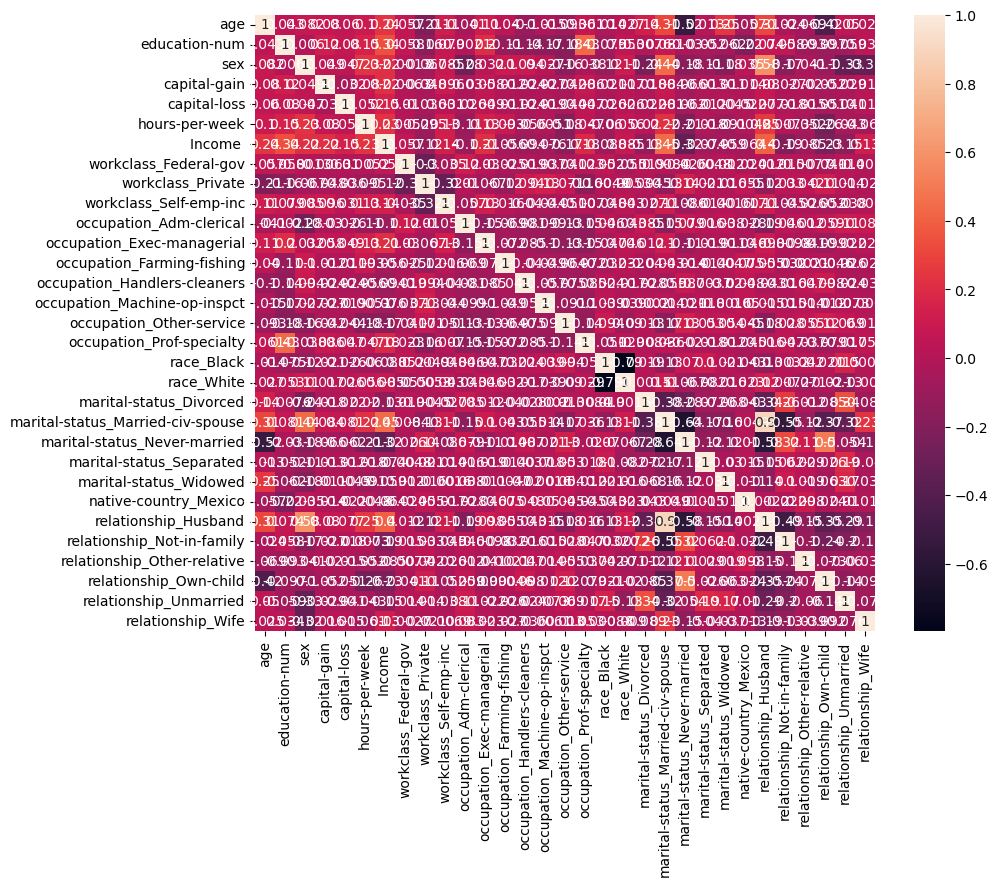

Index(['age', 'education-num', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'Income ', 'workclass_Federal-gov',
       'workclass_Private', 'workclass_Self-emp-inc',
       'occupation_Adm-clerical', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Prof-specialty', 'race_Black', 'race_White',
       'marital-status_Divorced', 'marital-status_Married-civ-spouse',
       'marital-status_Never-married', 'marital-status_Separated',
       'marital-status_Widowed', 'native-country_Mexico',
       'relationship_Husband', 'relationship_Not-in-family',
       'relationship_Other-relative', 'relationship_Own-child',
       'relationship_Unmarried', 'relationship_Wife'],
      dtype='object')

In [4]:
q1 = df['fnlwgt'].quantile(0.25)
q3 = df['fnlwgt'].quantile(0.75)
IQR = q3 - q1
# calculating the extremely high & low values
lowerBound = q1 - 1.5 * IQR
upperBound = q3 + 1.5 * IQR
# clip the extremely high & low values
df['fnlwgt'] = df['fnlwgt'].clip(lower=lowerBound, upper=upperBound)
# Correlate the data using corr
corr_data = df.corr()
top_feature = corr_data.index[abs(corr_data['Income ']) > 0.05]
plt.subplots(figsize=(10,8))
top_corr = df[top_feature].corr()
sns.heatmap(top_corr,annot=True)
plt.show()
top_feature


### Splitting Train dataset
##### split the data to train & validate to check the model on small bunch of data if it act well on it then we pass the test data totally to it, then we make `Feature Scaling` to scale all the numerical values in our data to be all in the same range, that make the model while training not biased to the Extremly high values & ignore the normal or the low ones, We use `StandartScaler()` to scale the data.
---

##### Now `x_train_scaled` contain the features that the model will train on it, `x_val_scaled` it the validation input to Validate & Check that the model act well.
---
###### **Note:** On the train data we make Fit then Transform function while scaling that's to make the model train and know all the data in the training `[Look at the data & make Rulebook]` while on Validation and Testing we make Transform only (apply) and that to make the data in the set converted to be ready to enter the model and checking or testing the model on the data found there 

In [5]:
data_input = df[top_feature]
data_input = data_input.drop(columns="Income ")
data_output = df['Income ']

#spliting the data into Train & Validate
x_train,x_val,y_train,y_val= train_test_split(data_input,data_output,test_size=0.2,random_state=0)

scalar = StandardScaler()
# look at the data & study it
scalar.fit(x_train)
# apply the rules of scaling
x_train_scaled = scalar.transform(x_train)
x_val_scaled = scalar.transform(x_val)

# retrieve column names
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_val_scaled = pd.DataFrame(x_val_scaled,columns=x_val.columns)

x_train_scaled


,age,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Private,workclass_Self-emp-inc,occupation_Adm-clerical,...,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,native-country_Mexico,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,0.120337,1.516682,0.694933,0.272995,-0.216765,0.763422,-0.179178,-1.689032,-0.191741,-0.37618,...,-0.686353,-0.183086,-0.166713,-0.143277,1.192476,-0.588350,-0.171641,-0.417371,-0.345259,-0.220817
1,-0.489564,1.125430,0.694933,-0.147632,-0.216765,0.763422,-0.179178,0.592055,-0.191741,-0.37618,...,1.456977,-0.183086,-0.166713,-0.143277,-0.838591,1.699668,-0.171641,-0.417371,-0.345259,-0.220817
2,0.044100,0.342927,0.694933,0.894514,-0.216765,-0.073303,-0.179178,0.592055,-0.191741,-0.37618,...,-0.686353,-0.183086,-0.166713,-0.143277,1.192476,-0.588350,-0.171641,-0.417371,-0.345259,-0.220817
3,-1.404416,-0.048324,0.694933,-0.147632,-0.216765,0.261387,-0.179178,0.592055,-0.191741,-0.37618,...,1.456977,-0.183086,-0.166713,-0.143277,-0.838591,-0.588350,-0.171641,2.395948,-0.345259,-0.220817
4,-1.251941,-0.439576,0.694933,-0.147632,-0.216765,-0.491666,-0.179178,0.592055,-0.191741,-0.37618,...,1.456977,-0.183086,-0.166713,-0.143277,-0.838591,-0.588350,-0.171641,-0.417371,2.896380,-0.220817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24106,-1.251941,0.734179,0.694933,-0.147632,-0.216765,-1.746753,5.581039,-1.689032,-0.191741,-0.37618,...,1.456977,-0.183086,-0.166713,-0.143277,-0.838591,-0.588350,-0.171641,2.395948,-0.345259,-0.220817
24107,0.654001,1.125430,0.694933,-0.147632,-0.216765,1.600147,5.581039,-1.689032,-0.191741,-0.37618,...,-0.686353,-0.183086,-0.166713,-0.143277,-0.838591,1.699668,-0.171641,-0.417371,-0.345259,-0.220817
24108,-0.642039,-0.439576,0.694933,-0.147632,-0.216765,-0.073303,-0.179178,0.592055,-0.191741,-0.37618,...,-0.686353,-0.183086,-0.166713,-0.143277,1.192476,-0.588350,-0.171641,-0.417371,-0.345259,-0.220817
24109,0.958952,-0.439576,0.694933,-0.147632,-0.216765,-0.073303,-0.179178,-1.689032,-0.191741,-0.37618,...,-0.686353,-0.183086,-0.166713,-0.143277,1.192476,-0.588350,-0.171641,-0.417371,-0.345259,-0.220817


## Test Data Preprocessing
#### We make all what we did in the Training data except the Correlation & Fitting the data just Apply (Transform).

In [6]:
# Recheck the file path before run.
test_df = pd.read_csv("../test_data.csv", na_values=['?'], skipinitialspace=True)
print("Number of duplicated rows in test data:",test_df.duplicated().sum(),'\n')
test_df = test_df.drop_duplicates()
test_df = test_df.drop(columns="education")

mask = test_df.isnull().any(axis=1)
print("Percentage of the rows that contain nulls from the main df after dropping the duplicated:",mask.sum() / len(test_df),'\n')
print("Number of rows before dropping null:",len(test_df),'\n')
test_df = test_df.dropna()
print("Number of rows after dropping null:",len(test_df))
# droping 7.5% from my data was vary columns not only one column or biased one

test_df.columns
test_df = pd.get_dummies(test_df, columns=['workclass', 'occupation', 'race',"marital-status","native-country","relationship"],dtype=int)
test_df.head()

test_income_dict = { '>50K.' : 1,'<=50K.' :0}
test_df['sex'] = test_df['sex'].replace(sex_dict).astype('int')
test_df['Income '] = test_df['Income '].replace(test_income_dict).astype('int')

#feature scalling for fnlwgt
test_df['fnlwgt'] = test_df['fnlwgt'].clip(lower=lowerBound, upper=upperBound)

#to ensure that the training data & test data have the same number of columns
test_input_all = test_df.reindex(columns=top_feature, fill_value=0)

x_test = test_input_all.drop(columns="Income ", errors='ignore')
y_test = test_df['Income ']
x_test_scaled = scalar.transform(x_test)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)


Number of duplicated rows in test data: 5 

Percentage of the rows that contain nulls from the main df after dropping the duplicated: 0.07501843204718604 

Number of rows before dropping null: 16276 

Number of rows after dropping null: 15055


C:\Users\youse\AppData\Local\Temp\ipykernel_7600\2581662257.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['sex'] = test_df['sex'].replace(sex_dict).astype('int')
C:\Users\youse\AppData\Local\Temp\ipykernel_7600\2581662257.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Income '] = test_df['Income '].replace(test_income_dict).astype('int')


## Models Training
##### Each model have `Hyperparameters` it isn't just a paramaters but is a values putted & tested to make the model act well while testing & validating, it's how the model will act with the data, what is the degree of stictness of classification or how the model will classify the data like Does the model will overfiting learn on the data or will underfit, How the model will act with noise so the accuracy, precision, recall & F1-Score might change according to changing one or more of these Hyperparameters.
---

### Some Definitions:
**Accuracy:** What is the difference between what the model predict & what it exist (like my output data `y`), as there is a huge difference the accuracy will be small else it will be high or good accuracy.

**Precision:** Of all Predicted Positives, How many were actually correct. `(Eq. = TP/(TP+FP))`

**Recall:** Of all Actual Positives, How many did we find ? `(Eq. = TP/TP+FN)`

---

##### Each model will follow these steps:
1. Initilaizing the Model & set Hyperparamaters.
2. Fit or Train it on x_train_scaled, y_train.
3. Test on **x_val_scaled**.
4. Test on **x_test_scaled**.
5. Show the Graphs, Figures, Confusion Matrices, Classification Reports & Accuracy after validation & testing.
6. Test & Train the model on more than one value of Hyperparameters to show the differences.
---

### SVM

We use a Support Vector Machine (SVM) classifier with an RBF kernel for the classification task.

After experimenting with different hyperparameters using a simple grid search on the validation set, the best performance was achieved with:

C = 1
gamma = 0.01
kernel = rbf

These parameters provide a good balance between model complexity and generalization ability, resulting in the highest validation accuracy.

##### SVM Accuracy & Report on Validate data.

Validation Accuracy : 0.8490378234903783 

Classification Report :  

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4543
           1       0.75      0.59      0.66      1485

    accuracy                           0.85      6028
   macro avg       0.81      0.76      0.78      6028
weighted avg       0.84      0.85      0.84      6028


================ Confusion Matrix ================



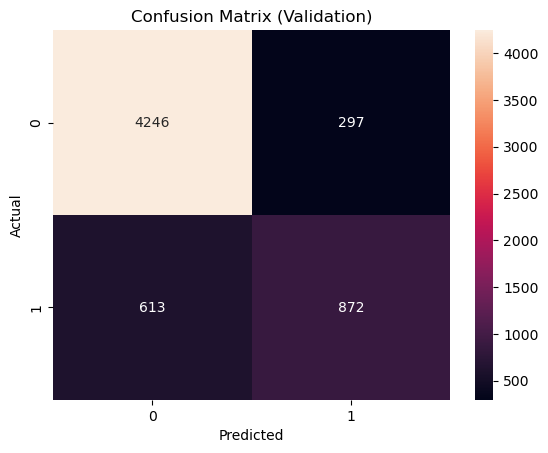

In [7]:
# creating svm model with best parameters
model = SVC(C=1, gamma=0.01, kernel='rbf')

# training svm model
model.fit(x_train_scaled, y_train)

# predictions on validation set
y_val_pred = model.predict(x_val_scaled)

# evaluate model performance
print("Validation Accuracy :" , accuracy_score(y_val, y_val_pred), '\n')
print("Classification Report :  \n")
print(classification_report(y_val, y_val_pred))
print("\n================ Confusion Matrix ================\n")

# confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



##### SVM report & Accuracy on Test data.

Test Accuracy: 0.8498173364330787 

Test Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90     11355
           1       0.75      0.58      0.65      3700

    accuracy                           0.85     15055
   macro avg       0.81      0.76      0.78     15055
weighted avg       0.84      0.85      0.84     15055



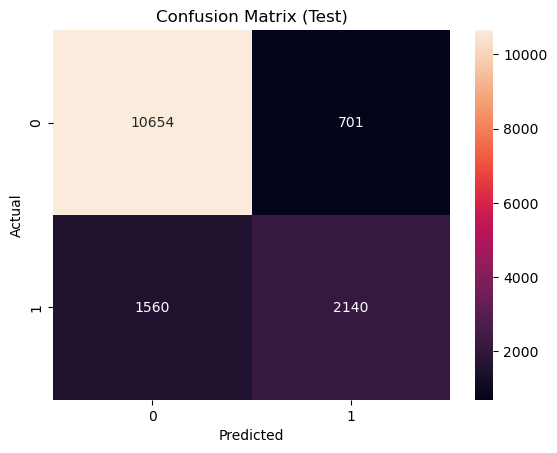

In [8]:

# testing model
y_test_pred = model.predict(x_test_scaled)


# accuracy
print("Test Accuracy:", accuracy_score(y_test, y_test_pred), "\n")


# classification report
print("Test Classification Report:\n")
print(classification_report(y_test, y_test_pred))

# confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure()
sns.heatmap(cm_test, annot=True, fmt='d')
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


We evaluate the trained SVM model on the test set to measure its final performance.  
The classification report shows precision, recall, and F1-score for each class.  
These metrics help us understand how well the model works on unseen data.

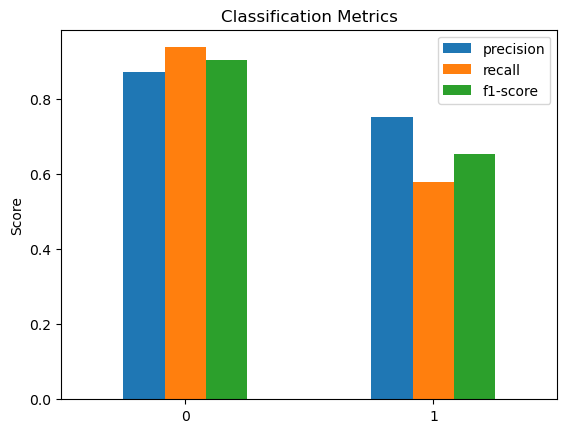

In [9]:
report = classification_report(y_test, y_test_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report = df_report.iloc[:2]
df_report[['precision','recall','f1-score']].plot(kind='bar')
plt.title("Classification Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### Decision Tree

In [10]:
max_depth = range(1,10)
train_acc_values = []
val_acc_values = []

for depth in max_depth :
  model = DecisionTreeClassifier(max_depth= depth, criterion= 'entropy', random_state= 2)
  model.fit(x_train_scaled, y_train)
  y_pred_train = model.predict(x_train_scaled)
  y_pred_val = model.predict(x_val_scaled)
  train_acc_values.append(accuracy_score(y_train, y_pred_train))
  val_acc_values.append(accuracy_score(y_val, y_pred_val))

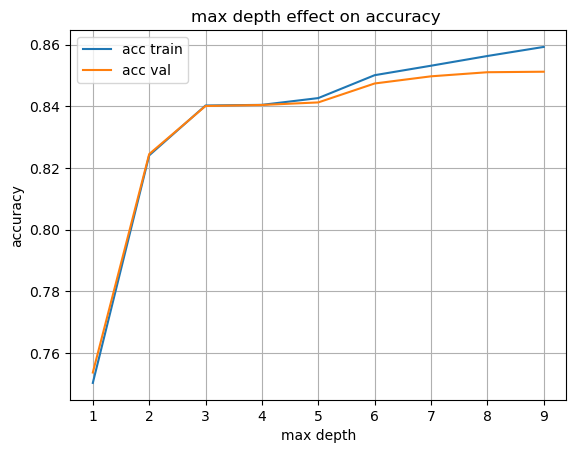

In [11]:
plt.plot(max_depth, train_acc_values, label = "acc train")
plt.plot(max_depth, val_acc_values, label = "acc val")
plt.legend()
plt.grid()
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.title('max depth effect on accuracy ')
plt.show()

the best depth is 8

In [12]:
best_model = DecisionTreeClassifier(max_depth= 8, criterion= 'entropy', random_state= 2)
best_model.fit(x_train_scaled, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


accuracy test

In [13]:
test_acc = accuracy_score(y_test, best_model.predict(x_test_scaled))
print("Test accuracy:", test_acc)

Test accuracy: 0.850614413816008


tree plot

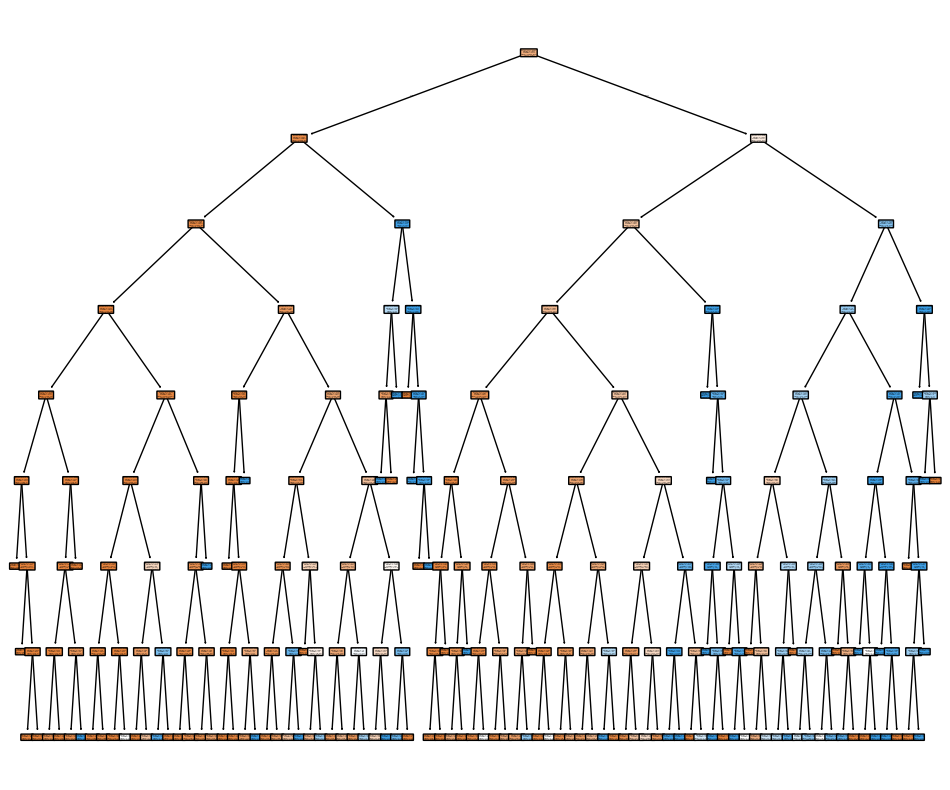

In [14]:
plt.figure(figsize=(12,10))
plot_tree(best_model, filled=True, feature_names=[f"Feature {i}" for i in range(x_train_scaled.shape[1])], class_names=['<=50K', '>50K'], rounded = True)
plt.show()


### Random Forest

In [15]:
# initializing the random forest classifier
rf = RandomForestClassifier()

**impleminting GridSearchCV to calculate the best value of each hyperparameter (tuing hyperparameters)**

In [16]:

# the grind that contains different values for 3 parameters
param_grid = {
    'n_estimators': [ 150 ,200 , 250 ],
    'max_depth': [ 2, 4 ,6 , 8 , 9 ],
    'criterion': ['gini', 'entropy']
}

# intializing gridSearchCV wiht cv = 4
grid = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = 'accuracy',
    cv = 4,
    n_jobs = -1
)

grid = grid.fit(x_train_scaled,y_train)

grid.best_params_

{'criterion': 'gini', 'max_depth': 9, 'n_estimators': 150}

**then the best value for each parameter is (Criterion = gini , Max Depth = 9 , n_estimators(number of decision trees) = 250)**

Training the model using these **values**

In [33]:
rf_best = RandomForestClassifier(criterion = 'gini' , max_depth = 9 , n_estimators = 250  )

# training the model
rf_best.fit(x_train_scaled,y_train)

# validation proccess
y_pred_train_rf = rf_best.predict(x_train_scaled)
y_pred_val_rf = rf_best.predict(x_val_scaled)

# printing accuracy scores
print("Train accuracy score:",accuracy_score(y_train,y_pred_train_rf))
print("Validation accuracy score:",accuracy_score(y_val,y_pred_val_rf))

Train accuracy score: 0.8619717141553648
Validation accuracy score: 0.8570006635700066



Confusion matrix and report for the validation proccess

In [34]:
conf_m_rf_val = confusion_matrix(y_val,y_pred_val_rf)
report_rf_val = classification_report(y_val,y_pred_val_rf)

print("Validation Score:", accuracy_score(y_val,y_pred_val_rf))
print("Validation Confusion Matrix:\n", conf_m_rf_val)
print("Validation Classification Report:\n", report_rf_val)

Validation Score: 0.8570006635700066
Validation Confusion Matrix:
 [[4339  204]
 [ 658  827]]
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91      4543
           1       0.80      0.56      0.66      1485

    accuracy                           0.86      6028
   macro avg       0.84      0.76      0.78      6028
weighted avg       0.85      0.86      0.85      6028



Now it is time to to test the model

In [35]:
y_pred_test_rf = rf_best.predict(x_test_scaled)
print("Test Score:", accuracy_score(y_test,y_pred_test_rf))

Test Score: 0.8558618399202923


Confution matrix and report for testing proccess

In [36]:
conf_m_rf_test = confusion_matrix(y_test,y_pred_test_rf)

report_rf_test = classification_report(y_test,y_pred_test_rf)

print("Test Score:", accuracy_score(y_test,y_pred_test_rf))
print("Test Confusion Matrix:\n", conf_m_rf_test)
print("Test Classification Report:\n", report_rf_test)

Test Score: 0.8558618399202923
Test Confusion Matrix:
 [[10833   522]
 [ 1648  2052]]
Test Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     11355
           1       0.80      0.55      0.65      3700

    accuracy                           0.86     15055
   macro avg       0.83      0.75      0.78     15055
weighted avg       0.85      0.86      0.85     15055



After trying different values for each hyperParametr we found that max_depth is the most effective hyperParameter



Trying different values for max_depth

In [37]:
max_depth = [1,3,5,7,9,11,13,15,17]
train_acc_values_rf = []
val_acc_values_rf = []
for depth in max_depth :
  rf_model = RandomForestClassifier(criterion = 'gini' , max_depth = depth , n_estimators = 250  )
  rf_model.fit(x_train_scaled, y_train)
  y_pred_train = rf_model.predict(x_train_scaled)
  y_pred_val = rf_model.predict(x_val_scaled)
  train_acc_values_rf.append(accuracy_score(y_train, y_pred_train))
  val_acc_values_rf.append(accuracy_score(y_val, y_pred_val))

Drawing the results as a figure

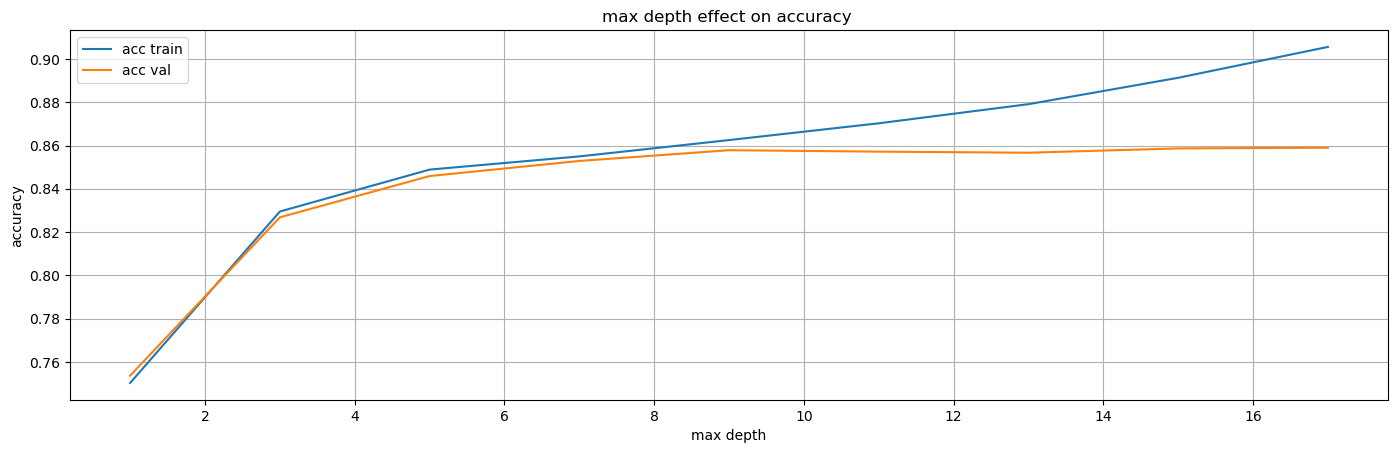

In [38]:
plt.figure().set_figwidth(17)
plt.plot(max_depth, train_acc_values_rf, label = "acc train")
plt.plot(max_depth, val_acc_values_rf, label = "acc val")
plt.legend()
plt.grid()
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.title('max depth effect on accuracy ')
plt.show()

### Logostic Regression

Validation Score: 0.8462176509621765 



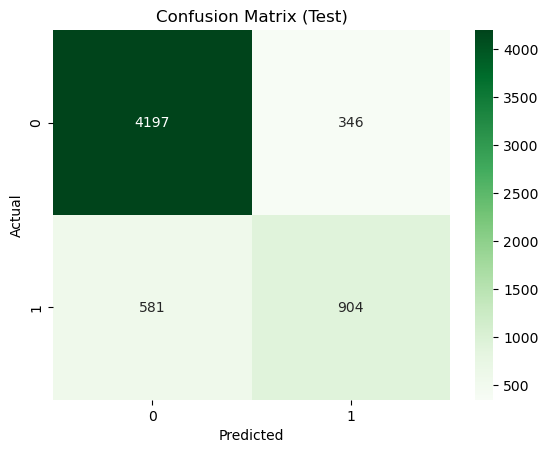


---------------------------------------

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      4543
           1       0.72      0.61      0.66      1485

    accuracy                           0.85      6028
   macro avg       0.80      0.77      0.78      6028
weighted avg       0.84      0.85      0.84      6028



In [39]:

# create a model train model & try C (0.001,0.01,0.1,1,10,100)
model = LogisticRegression(solver='liblinear', C=10 ,random_state=0)
model.fit(x_train_scaled,y_train)


#evaluate the model on the validation set
y_pred_val = model.predict(x_val_scaled)

score = model.score(x_val_scaled,y_val)
y_pred_train = model.predict(x_train_scaled)
conf_m = confusion_matrix(y_val,y_pred_val)

report = classification_report(y_val,y_pred_val)

print("Validation Score:", score,'\n')
plt.figure()
sns.heatmap(conf_m, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print('\n---------------------------------------\n')
print("Validation Classification Report:\n", report)


Test Score: 0.8481567585519761 



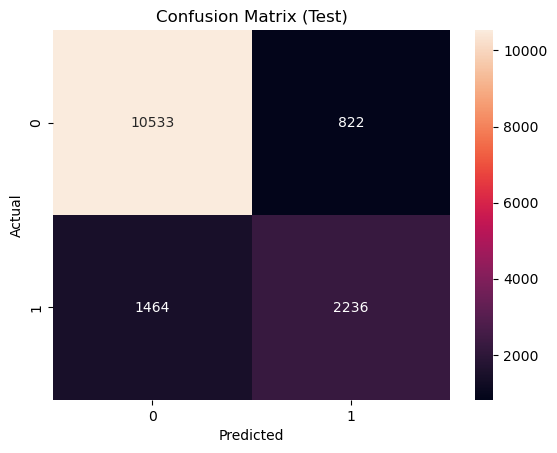


-------------------------------------------

Test Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90     11355
           1       0.73      0.60      0.66      3700

    accuracy                           0.85     15055
   macro avg       0.80      0.77      0.78     15055
weighted avg       0.84      0.85      0.84     15055



In [40]:
# evaluat the model in test
y_pred_val = model.predict(x_test_scaled)

score = model.score(x_test_scaled,y_test)

conf_m = confusion_matrix(y_test,y_pred_val)

report = classification_report(y_test,y_pred_val)

print("Test Score:", score,'\n')
plt.figure()
sns.heatmap(conf_m, annot=True, fmt='d')
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\n-------------------------------------------\n")
print("Test Classification Report:\n", report)
